# 01 — A two-line latency model has a model-dependent breakpoint.

The additive selection objective assigns a cost $T[|C|]$ to each contiguous chunk. Replacing that table by a structured function can simplify the optimization, but the boundary in the function need not coincide with a physical saturation point.

The notebook contains both acquisition and analysis. **An existing `block_estimates.csv` is read as-is. If it is absent, Run All measures the local storage and creates it.** Set `RERUN_MEASUREMENTS = True` only to replace an existing CSV. Acquisition is the slow, Linux-only part; cached analysis needs no hardware measurement or project Python files.

The supplied CSV was measured with the native six-worker reader. The independent Python reader below keeps the size/count sweep and throughput estimator, but has different scheduling overhead, reusable destination buffers and explicit alignment padding. Its results describe a **new reader profile**, not a reproduction of the native timings. All numerical tables, figures and fitted values below are calculated from the selected data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from IPython.display import Markdown, display
from pathlib import Path

CSV_PATH = Path("block_estimates.csv")
RERUN_MEASUREMENTS = False
SIZES_KIB = np.r_[np.arange(1, 257), np.arange(260, 769, 4)]
COUNTS = np.array([1, 2, 4, 8, 16, 28, 32, 48, 64, 96, 128, 192, 256, 384, 512])
BLOCKS, ITERS, WARMUP, THREADS, BLOB_MIB = 7, 10, 3, 6, 128
GAP_KIB, ALIGNMENT = 32, 4096

## The count sweep converts read times into a chunk cost.

For a logical length $x$ KiB and a count $n_j$, let $t_j$ be the median batch time in seconds after discarding the warmups. Define

$$m_j=\frac{n_jx}{1024}\quad\text{MiB},\qquad B_j=\frac{m_j}{t_j}\quad\text{MiB/s}.$$

Let $\overline B_j$ be the centered three-point mean. The first index $j\ge1$ with $|(\overline B_j-\overline B_{j-1})/(m_j-m_{j-1})|<0.05\max_k B_k$ starts the averaged tail. With no such index, use the last 20% of count points; with fewer than three points, use the last one. Then

$$\widehat T_b(x)=\frac{1000x}{1024\widehat B_b(x)}\quad\text{ms/chunk}.$$

This is the original throughput-estimation rule, not evidence that every count sweep reaches a true plateau.

In [2]:
def saturated_throughput(size, counts, seconds):
    total_mib = np.asarray(counts) * size / 1024
    throughput = total_mib / seconds
    if len(counts) < 3:
        return throughput[-1]
    smooth = pd.Series(throughput).rolling(3, center=True, min_periods=1).mean().to_numpy()
    slope = np.diff(smooth) / np.diff(total_mib)
    crossings = np.flatnonzero(np.abs(slope) < .05 * throughput.max())
    start = crossings[0] + 1 if len(crossings) else int(.8 * len(counts))
    return throughput[start:].mean()

### Direct reads are needed only when generating the data.

The reader requests `O_DIRECT` and uses six Python workers. Logical chunks are separated by a 32 KiB gap; each physical read is rounded outwards to 4096-byte boundaries. Throughput counts **logical** bytes, not padding. Anonymous `mmap` supplies aligned destination memory; it does not map the file or substitute a cached file read. Batch time includes Python worker dispatch and completion.

Put the CSV beside this notebook **on the target SSD**, not on a RAM filesystem. Only a temporary random file is written; no raw device is opened. File initialization is outside the timed interval. Unsupported direct I/O and short reads raise ordinary errors; there is no buffered-I/O fallback.

In [3]:
def batch_seconds(fd, size, count, buffer, stride):
    import os
    from time import perf_counter
    from concurrent.futures import ThreadPoolExecutor

    workers = min(THREADS, int(count))
    def read_lane(lane):
        for i in range(lane, int(count), workers):
            offset = i * (int(size) + GAP_KIB) * 1024
            aligned = offset // ALIGNMENT * ALIGNMENT
            length = ((offset - aligned + int(size) * 1024 + ALIGNMENT - 1)
                      // ALIGNMENT * ALIGNMENT)
            with memoryview(buffer)[lane * stride:lane * stride + length] as target:
                if os.preadv(fd, [target], aligned) != length:
                    raise OSError("Short O_DIRECT read")
    start = perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        list(pool.map(read_lane, range(workers)))
    return perf_counter() - start

In [4]:
def measure(directory):
    import os, mmap
    from tempfile import NamedTemporaryFile

    flags = os.O_RDONLY | os.O_DIRECT
    rng = np.random.default_rng(0)
    stride = ((int(max(SIZES_KIB)) * 1024 + 2 * ALIGNMENT - 1) // ALIGNMENT) * ALIGNMENT
    rows = []
    with NamedTemporaryFile(dir=directory) as blob:
        os.posix_fallocate(blob.fileno(), 0, BLOB_MIB * 1024**2)
        for _ in range(BLOB_MIB):
            blob.write(rng.bytes(1024**2))
        blob.flush()
        os.fsync(blob.fileno())
        with os.fdopen(os.open(blob.name, flags), "rb", buffering=0) as direct, \
                mmap.mmap(-1, THREADS * stride) as buffer:
            for block in range(BLOCKS):
                for order, size in enumerate(rng.permutation(SIZES_KIB)):
                    counts = COUNTS[COUNTS * (size + GAP_KIB) <= BLOB_MIB * 1024]
                    seconds = []
                    for count in counts:
                        trials = [batch_seconds(direct.fileno(), size, count, buffer, stride)
                                  for _ in range(WARMUP + ITERS)]
                        seconds.append(np.median(trials[WARMUP:]))
                    rate = saturated_throughput(size, counts, np.asarray(seconds))
                    rows.append(dict(block=block, order=order, size_kib=size,
                        latency_ms=1000 * size / (1024 * rate), throughput_mib_s=rate))
                print(f"Measured block {block + 1}/{BLOCKS}")
    return pd.DataFrame(rows).assign(reader="Python preadv; 4096-byte alignment")

In [5]:
if CSV_PATH.is_file() and not RERUN_MEASUREMENTS:
    data = pd.read_csv(CSV_PATH)
else:
    data = measure(CSV_PATH.parent)
    data.to_csv(CSV_PATH, index=False)

## The measurements define an amortized cost.

Let $x>0$ be logical chunk length in KiB. In measurement block $b$, the count sweep gives $\widehat T_b(x)$ as defined above. This is a throughput-derived amortized cost, not the service time of one isolated read.

Define $T(x)$ as the median over all blocks. The first four define $T_{\rm train}$; the remaining blocks define $T_{\rm test}$. Coefficients and free breakpoints use the training curve only. The supplied native reference contains seven blocks; a newly generated CSV contains the Python reader's estimates instead.

In [6]:
wide = data.pivot(index="size_kib", columns="block", values="latency_ms")
wide = wide.sort_index().sort_index(axis=1)
x, samples = wide.index.to_numpy(), wide.to_numpy()
T = np.median(samples, axis=1)
T_train = np.median(samples[:, :4], axis=1)
T_test = np.median(samples[:, 4:], axis=1)

## The minimum cost per byte is not a sustained throughput plateau.

Define the cost per KiB and its minimizing length by

$$\rho(x)=\frac{T(x)}x,\qquad x_\rho\in\arg\min_{x\in\mathcal G}\rho(x).$$

Since $B(x)=1000/(1024\rho(x))$, minimizing cost per byte is equivalent to maximizing throughput on the same curve. The alternative first-crossing rule uses a three-point median $\widetilde B_{\rm train}$:

$$s_{99}=\min\{x\in\mathcal G:\widetilde B_{\rm train}(x)\ge0.99\max_{u\in\mathcal G}\widetilde B_{\rm train}(u)\}.$$

These are different operations on different summaries of the same run.

In [7]:
rho = T / x
x_rho = x[np.argmin(rho)]
B = 1000 * x / (1024 * T_train)
B_smooth = pd.Series(B).rolling(3, center=True, min_periods=1).median().to_numpy()
s99 = x[np.flatnonzero(B_smooth >= .99 * B_smooth.max())[0]]
pd.Series({"Minimum cost per KiB": x_rho, "First 99% crossing": s99}, name="KiB")

Minimum cost per KiB    240
First 99% crossing      256
Name: KiB, dtype: int64

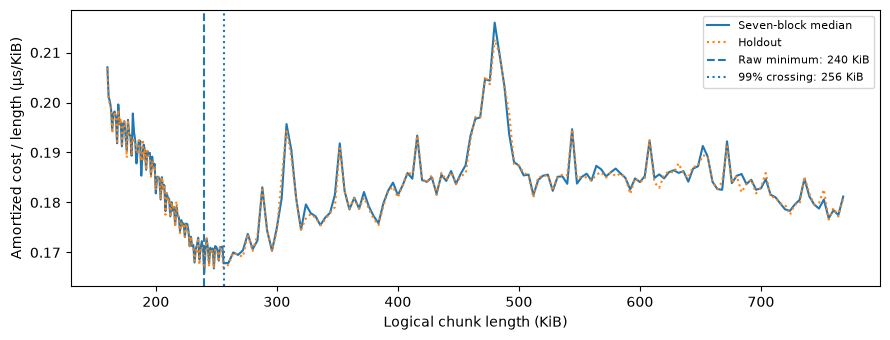

In [8]:
zoom = x >= 160
plt.figure(figsize=(9, 3.5))
plt.plot(x[zoom], 1000 * rho[zoom], label="Seven-block median")
plt.plot(x[zoom], 1000 * T_test[zoom] / x[zoom], ":", label="Holdout")
plt.axvline(x_rho, ls="--", label=f"Raw minimum: {x_rho:g} KiB")
plt.axvline(s99, ls=":", label=f"99% crossing: {s99:g} KiB")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Amortized cost / length (µs/KiB)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
display(Markdown(
    f"**Figure 1.** The minimum is **{1000 * rho.min():.4f} µs/KiB at {x_rho:g} KiB**. "
    "The view starts at 160 KiB to expose variation around the minimum. "
    f"The smoothed training curve first crosses 99% at **{s99:g} KiB**; "
    "the following statistics test whether that level is sustained."))

**Figure 1.** The minimum is **0.1660 µs/KiB at 240 KiB**. The view starts at 160 KiB to expose variation around the minimum. The smoothed training curve first crosses 99% at **256 KiB**; the following statistics test whether that level is sustained.

In [10]:
tail = x >= s99
q = T_test[tail] / x[tail]
pd.Series({
    "Tail points": tail.sum(),
    "Below 99%": np.sum(B_smooth[tail] < .99 * B_smooth.max()),
    "Cost/length CV (%)": 100 * q.std(ddof=1) / q.mean(),
    "Endpoint change (%)": 100 * (q[-1] / q[0] - 1),
}).round(3)

Tail points            129.000
Below 99%              125.000
Cost/length CV (%)       4.027
Endpoint change (%)      8.356
dtype: float64

## A boundary fixed at 240 KiB gives a useful two-line approximation.

Consider the continuous family, for $x>0$,

$$\boxed{T_s(x)=c_1x+\delta\max(s,x)
=\begin{cases}\delta s+c_1x,&x\le s,\\(c_1+\delta)x,&x\ge s,\end{cases}
\qquad c_1,\delta\ge0.}$$

Continuity ties the short-chunk intercept to the boundary, $a=\delta s$. The long-chunk line passes through the origin, so $T_s(x)/x=c_1+\delta$ is constant after $s$. This is a restriction on the model, not an observed identity.

For a fixed $s$, the design matrix has rows $(x,\max(s,x))$. Nonnegative least squares fits its two coefficients to $T_{\rm train}$. **Every model in this report has fitted coefficients; fixed and free refer only to the breakpoint.**

In [11]:
def X_s(s):
    return np.column_stack((x, np.maximum(s, x)))


def T_s(s):
    return X_s(s) @ nnls(X_s(s), T_train)[0]


c1, delta = nnls(X_s(240), T_train)[0]
pd.Series({"Short intercept (ms)": 240 * delta,
           "Short slope (ms/KiB)": c1, "Long slope (ms/KiB)": c1 + delta})

Short intercept (ms)    0.011369
Short slope (ms/KiB)    0.000136
Long slope (ms/KiB)     0.000183
dtype: float64

The coefficients above define the 240 KiB model without claiming that the measured tail is flat.

## Fitting the boundary is not the same as finding the efficiency minimum.

Let $\mathcal G^\circ$ be the measured grid without its first and last three sizes. The free boundary minimizes **training** error within the constrained family:

$$\boxed{s_\star\in\arg\min_{s\in\mathcal G^\circ}
\min_{c_1,\delta\ge0}\frac1{|\mathcal G|}\sum_{x\in\mathcal G}
[T_{\rm train}(x)-c_1x-\delta\max(s,x)]^2.}$$

The objective weights measured sizes equally. RMSE has the same minimizer as MSE and is easier to display in units of time.

In [12]:
def rmse(observed, predicted):
    return np.sqrt(np.mean((observed - predicted) ** 2))


G = x[3:-3]
E_s = np.array([rmse(T_train, T_s(s)) for s in G])
s_star = G[np.argmin(E_s)]

A continuous hinge instead has the form

$$T_H(x)=a+bx+d(x-h)_+.$$

Its coefficients are unconstrained least-squares estimates, and $h$ is selected on the same training grid. For $x\ge h$, its tail is $(a-dh)+(b+d)x$, whose intercept need not vanish. A free-boundary constrained model has three parameters; a free hinge has four. Their boundaries therefore need not agree.

In [13]:
def X_h(h):
    return np.column_stack((np.ones_like(x), x, np.maximum(x - h, 0)))


def T_h(h):
    return X_h(h) @ np.linalg.lstsq(X_h(h), T_train, rcond=None)[0]


E_h = np.array([rmse(T_train, T_h(h)) for h in G])
h_star = G[np.argmin(E_h)]
a, b, d = np.linalg.lstsq(X_h(h_star), T_train, rcond=None)[0]
band = G[E_s <= 1.01 * E_s.min()]
pd.Series({"Two-line boundary (KiB)": s_star, "Hinge boundary (KiB)": h_star,
           "Hinge tail intercept (µs)": 1000 * (a - d * h_star),
           "1% RMSE band, lower (KiB)": band.min(), "Upper (KiB)": band.max()}).round(3)

Two-line boundary (KiB)      211.000
Hinge boundary (KiB)         230.000
Hinge tail intercept (µs)     -2.645
1% RMSE band, lower (KiB)    198.000
Upper (KiB)                  224.000
dtype: float64

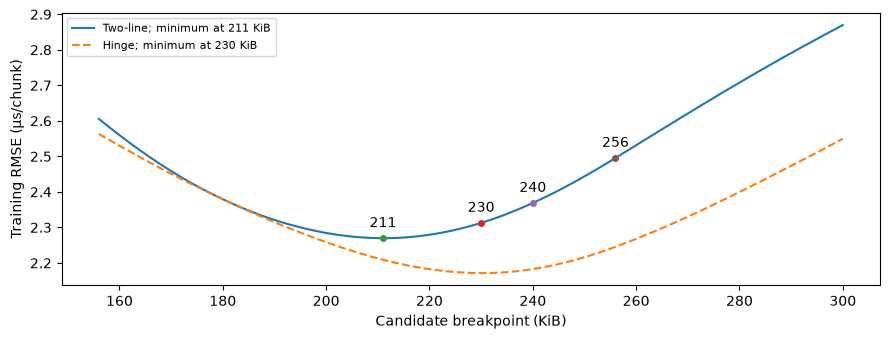

In [14]:
local = (G >= min(s_star, h_star, 230) - 55) & (G <= max(s_star, h_star, 256) + 45)
plt.figure(figsize=(9, 3.5))
plt.plot(G[local], 1000 * E_s[local], label=f"Two-line; minimum at {s_star:g} KiB")
plt.plot(G[local], 1000 * E_h[local], "--", label=f"Hinge; minimum at {h_star:g} KiB")
for s in (s_star, 230, 240, 256):
    error = 1000 * rmse(T_train, T_s(s))
    plt.plot(s, error, "o", ms=4)
    plt.annotate(f"{s:g}", (s, error), xytext=(0, 8), textcoords="offset points", ha="center")
plt.xlabel("Candidate breakpoint (KiB)")
plt.ylabel("Training RMSE (µs/chunk)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Figure 2.** Each point refits its family's coefficients at the candidate boundary. The circles mark the nominated lengths in the constrained family. Neither search uses holdout error.

The preceding results give the two fitted boundaries and the hinge's tail intercept; the constrained family's tail intercept is zero. Fixing $T_s$ at the hinge location does not make it the hinge model. The displayed 1% RMSE range is an objective-sensitivity set, **not a confidence interval**. A boundary minimizing fitting error is not necessarily an optimal physical read size.


## Holdout errors compare the fitted functions, not SSD speeds.

Fit the coefficients again at each fixed boundary, and keep every fit frozen for evaluation. Include the affine baseline $T_A(x)=a+bx$. Define

$$\mathrm{RMSE}=\sqrt{\frac1{|\mathcal G|}\sum_x[\widehat T(x)-T_{\rm test}(x)]^2},\qquad
\mathrm{MAPE}=\frac{100}{|\mathcal G|}\sum_x\frac{|\widehat T(x)-T_{\rm test}(x)|}{T_{\rm test}(x)}.$$

In [15]:
predictions = {}
for s in (240, 256, 230):
    predictions[f"Two-line ({s} KiB)"] = T_s(s)
free_line = f"Two-line ({s_star:g} KiB, free)"
free_hinge = f"Hinge ({h_star:g} KiB, free)"
predictions[free_line] = T_s(s_star)
predictions[free_hinge] = T_h(h_star)
X_a = np.column_stack((np.ones_like(x), x))
predictions["Affine"] = X_a @ np.linalg.lstsq(X_a, T_train, rcond=None)[0]

In [16]:
rows = []
for name, prediction in predictions.items():
    rows.append({"Model": name,
                 "Train RMSE (µs)": 1000 * rmse(T_train, prediction),
                 "Holdout RMSE (µs)": 1000 * rmse(T_test, prediction),
                 "Holdout MAPE (%)": 100 * np.mean(np.abs(prediction - T_test) / T_test)})
comparison = pd.DataFrame(rows).set_index("Model")
comparison.round(3)

,Train RMSE (µs),Holdout RMSE (µs),Holdout MAPE (%)
Model,,,
Two-line (240 KiB),2.369,2.323,3.803
Two-line (256 KiB),2.496,2.456,4.267
Two-line (230 KiB),2.313,2.265,3.592
"Two-line (211 KiB, free)",2.270,2.218,3.332
"Hinge (230 KiB, free)",2.171,2.094,2.919
Affine,3.819,3.816,10.004


In [17]:
gain = 100 * (1 - comparison.loc["Two-line (240 KiB)", "Holdout RMSE (µs)"]
              / comparison.loc["Two-line (256 KiB)", "Holdout RMSE (µs)"])
best_model = comparison["Holdout RMSE (µs)"].idxmin()
display(Markdown(
    f"Replacing the 256 KiB anchor with 240 KiB changes holdout RMSE by **{-gain:+.2f}%**. "
    f"The lowest holdout RMSE here is obtained by **{best_model}**. "
    "These compare prediction errors, **not SSD speeds**; the hinge also has a less restrictive tail."))

Replacing the 256 KiB anchor with 240 KiB changes holdout RMSE by **-5.39%**. The lowest holdout RMSE here is obtained by **Hinge (230 KiB, free)**. These compare prediction errors, **not SSD speeds**; the hinge also has a less restrictive tail.

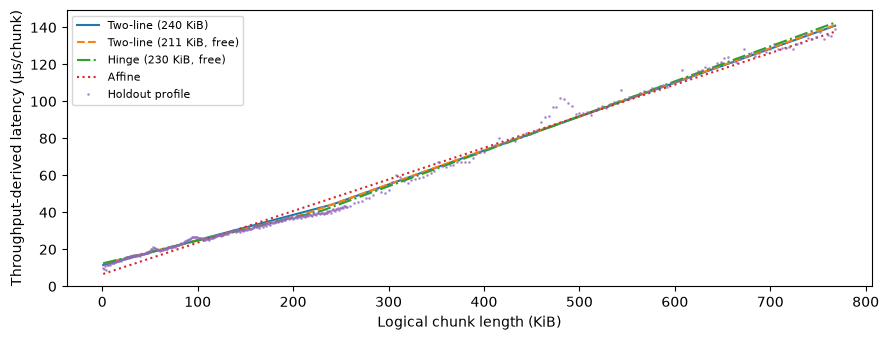

In [18]:
main_models = ["Two-line (240 KiB)", free_line, free_hinge]
plt.figure(figsize=(9, 3.5))
for name, style in zip(main_models + ["Affine"], ["-", "--", "-.", ":"]):
    plt.plot(x, 1000 * predictions[name], style, label=name)
plt.plot(x, 1000 * T_test, ".", ms=2, alpha=.6, label="Holdout profile")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Throughput-derived latency (µs/chunk)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Figure 3.** Training-fitted curves against the held-out blocks. The structured models are close at this scale; their residuals expose the remaining differences.

## The approximation does not remove the residual structure.

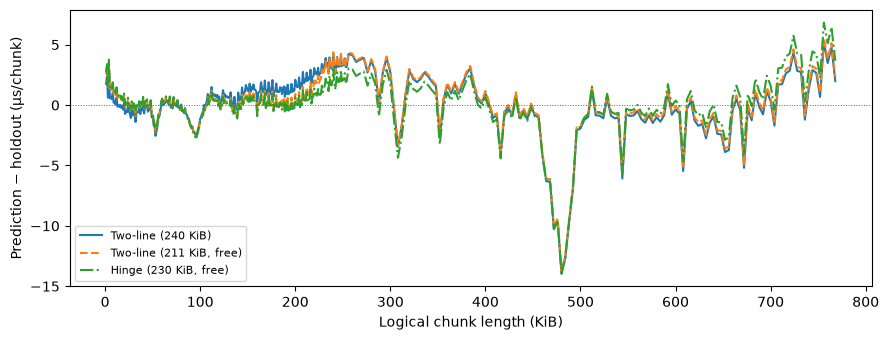

In [19]:
plt.figure(figsize=(9, 3.5))
for name, style in zip(main_models, ["-", "--", "-."]):
    plt.plot(x, 1000 * (predictions[name] - T_test), style, label=name)
plt.axhline(0, ls=":", lw=.7)
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Prediction − holdout (µs/chunk)")
plt.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

**Figure 4.** Negative residuals indicate underestimated latency. Local departures shared by the fitted curves are not explained away by moving the breakpoint. In the supplied native reference, a departure near 480 KiB remains under both free-boundary models; a new acquisition must be interpreted from its own residuals.

The four displayed lengths answer different questions: $s_{99}$ is a smoothed throughput crossing, $x_\rho$ minimizes measured cost per byte, $h_\star$ minimizes hinge error, and $s_\star$ minimizes constrained two-line error. None alone proves that a chunking policy improves the lookup-table objective; guarantees derived for $T_s$ remain conditional on that model.

### Scope

The supplied reference has **256 / 240 / 230 / 211 KiB** for these four quantities. It came from a native six-worker run with seven randomized blocks, 384 sizes, three warmups and ten timed batches per count. The fixed candidates were nominated after inspection of that run; 240 KiB is its **all-seven-block** efficiency minimum. That comparison is retrospective, not a fresh confirmatory holdout experiment.

The notebook can now generate a new profile, but its Python worker overhead and 4096-byte physical padding differ from the native reader. The historical numbers are not predictions for the new reader or another SSD. Tables and plots recompute from the selected CSV; both free-boundary searches still use training data only. The optimum depends on the model, loss, grid and reader, and extrapolation beyond the measured range is not established.

In [20]:
pd.Series({"99% crossing": s99, "Minimum cost/length": x_rho,
           "Hinge boundary": h_star, "Two-line boundary": s_star}, name="KiB")

99% crossing           256
Minimum cost/length    240
Hinge boundary         230
Two-line boundary      211
Name: KiB, dtype: int64